# Clayton Copula for Portfolio Risk Analysis

This notebook demonstrates the implementation and usage of Clayton copula for portfolio risk analysis. The Clayton copula is particularly useful in finance as it exhibits strong lower tail dependence, making it suitable for modeling the tendency of assets to crash together during market downturns.

Key features of this implementation:
- Transforms return data into pseudo-observations using empirical distribution
- Fits a Clayton copula to capture the dependence structure between assets
- Calculates Value at Risk (VaR) and Conditional Value at Risk (CVaR)
- Handles portfolio weights and returns data efficiently

The Clayton copula provides a robust way to model asymmetric dependence in financial returns, particularly useful for risk management and portfolio optimization.


## Setup

In [2]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Basic Statistics:
             ^GSPC        ^FTSE        ^N225       ^GDAXI
count  6898.000000  6898.000000  6898.000000  6898.000000
mean      0.000339     0.000141     0.000239     0.000353
std       0.012280     0.011468     0.014493     0.014547
min      -0.119841    -0.108738    -0.123958    -0.122386
25%      -0.004886    -0.005076    -0.006593    -0.006309
50%       0.000642     0.000295     0.000000     0.000614
75%       0.006092     0.005700     0.007484     0.007408
max       0.115800     0.098387     0.141503     0.114020


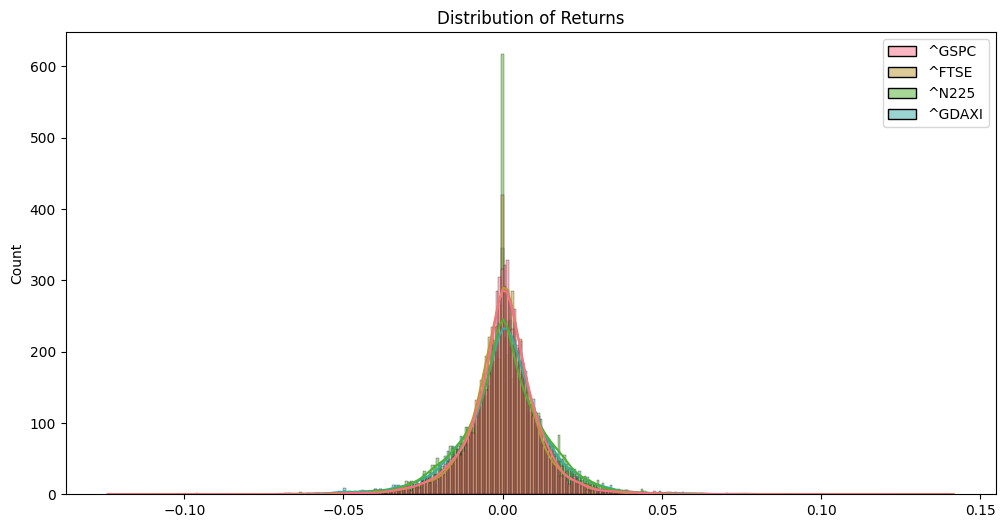

In [3]:
from helper import get_data
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_palette('husl')

df = get_data(["^GSPC", "^FTSE", "^N225", "^GDAXI"])
returns = df.pct_change().dropna()

# Basic statistics
print("Basic Statistics:")
print(returns.describe())


# Plot returns distribution
plt.figure(figsize=(12, 6))
sns.histplot(returns, kde=True)
plt.title('Distribution of Returns')
plt.show()

# Clayton Copula Analysis

## Overview
The Clayton copula is an Archimedean copula that exhibits asymmetric tail dependence, making it particularly suitable for modeling financial returns where extreme negative events tend to occur together more frequently than extreme positive events.

## Key Characteristics
- **Asymmetric Tail Dependence**: 
  - Strong lower tail dependence
  - Upper tail independence
  - Perfect for modeling joint extreme losses

- **Dependence Structure**:
  - Parameter θ > 0 controls dependence strength
  - θ → ∞: Perfect positive dependence
  - θ → 0: Independence
  - Higher θ: Stronger lower tail dependence

## Implementation Details
1. **Data Transformation**:
   - Returns are transformed to pseudo-observations
   - Empirical distribution function used for marginal transformations
   - Preserves the dependence structure while standardizing margins

2. **Copula Fitting**:
   - Uses pyvinecopulib for efficient implementation
   - Automatically estimates the dependence parameter θ
   - Handles high-dimensional data efficiently

3. **Risk Metrics**:
   - Value at Risk (VaR) calculation
   - Conditional Value at Risk (CVaR)
   - Focus on extreme negative events

## Visualizations
The notebook includes several visualizations to understand the copula's properties:

1. **Scatter Matrix Plot**:
   - Shows asymmetric dependence structure
   - KDE on diagonal shows marginal distributions
   - Clustering in lower tail visible in off-diagonal plots

2. **Pairwise Scatter Plots**:
   - Detailed view of specific pairs
   - Different colors for each pair
   - Clear visualization of lower tail dependence

3. **3D Visualization**:
   - Three-dimensional view of the copula
   - Fourth dimension represented by color
   - Shows clustering in lower tail

4. **Returns Distribution**:
   - KDE plot of portfolio returns
   - VaR line indicating risk threshold
   - Heavy lower tail visible

## Interpretation
- The scatter plots show stronger clustering in the lower tail
- The KDE plots reveal the asymmetric nature of the dependence
- The 3D plot helps visualize the complex dependence structure
- The returns distribution shows the impact of lower tail dependence

## Applications
- Portfolio risk management
- Insurance risk modeling
- Credit risk analysis
- Market risk assessment
- Stress testing scenarios

## Advantages
- Captures asymmetric tail dependence
- Suitable for modeling joint extreme losses
- Efficient implementation
- Good for high-dimensional data

## Limitations
- Only models lower tail dependence
- May not capture complex dependence structures
- Parameter estimation can be challenging

## Next Steps
- Compare with Gaussian and Student-t copulas
- Analyze sensitivity to parameter θ
- Explore different marginal distributions
- Implement additional risk metrics

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import pyvinecopulib as pv
import numpy as np

returns = returns.to_numpy()

# Simulated distributions
N = 100000
(_size, n_assets) = returns.shape

# Get empirical distribution
U_empirical = pv.to_pseudo_obs(returns)


# Fit a Gaussian vine
controls = pv.FitControlsVinecop(family_set=[pv.BicopFamily.clayton])
cop = pv.Vinecop.from_data(U_empirical, controls=controls)
U = cop.simulate(N)

# First, let's check the dimensions
print("Shape of returns:", returns.shape)
print("Shape of U:", U_empirical.shape)

# Calculate quantiles more safely
U_scaled = np.empty_like(U)
for i in range(n_assets):
    U_scaled[:, i] = np.quantile(returns[:, i], U[:, i])

Shape of returns: (6898, 4)
Shape of U: (6898, 4)


## Scatter Matrix of Simulated Clayton Copula Returns
- Below is a scatter matrix plot visualizing the simulated asset returns generated using the Clayton copula. Each subplot shows the relationship between pairs of assets, allowing us to observe the dependence structure and joint behavior captured by the copula model. The diagonal plots display the distribution of each asset's returns, while the off-diagonal plots reveal how the assets co-move, highlighting the lower tail dependence characteristic of the Clayton copula.


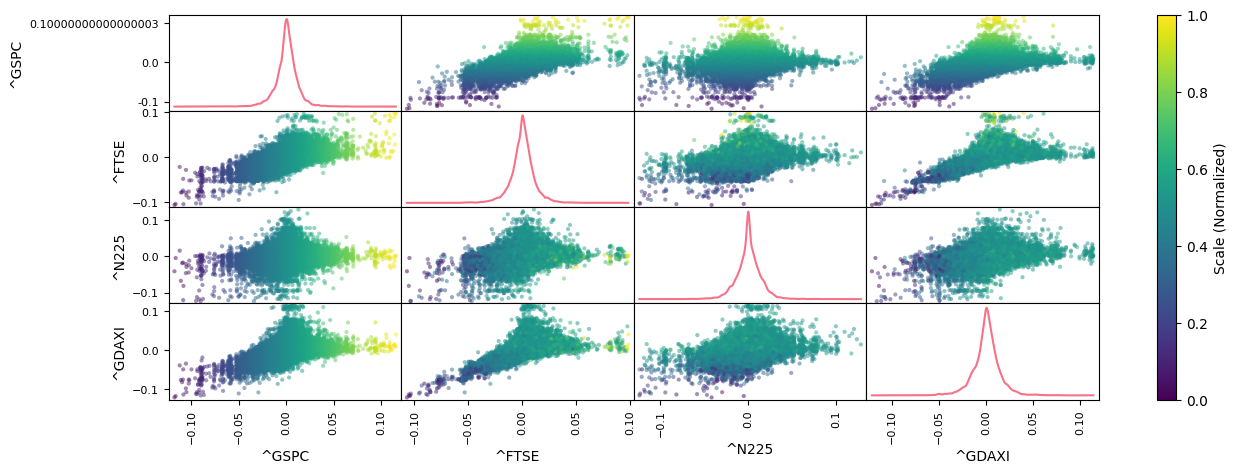

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(U_scaled)
df.columns = ["^GSPC", "^FTSE", "^N225", "^GDAXI"]

colors = df["^GSPC"].values 

# Create the scatter matrix with colors
pd.plotting.scatter_matrix(df, alpha=0.5, figsize=(15, 5), diagonal='kde', c=colors, cmap='viridis')

# Add a colorbar to show the mapping of color to U4
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gcf().axes)
cbar.set_label('Scale (Normalized)')

plt.show()

## 3D Visualization of Clayton Copula Dependence Structure
- This section provides a 3D visualization of the simulated data generated from the Clayton copula. By plotting three of the simulated asset return dimensions against each other and using a fourth as the color, we can visually inspect the dependence structure and tail behavior captured by the copula model. This helps to better understand the joint distribution and the relationships between the assets as modeled by the Clayton copula.

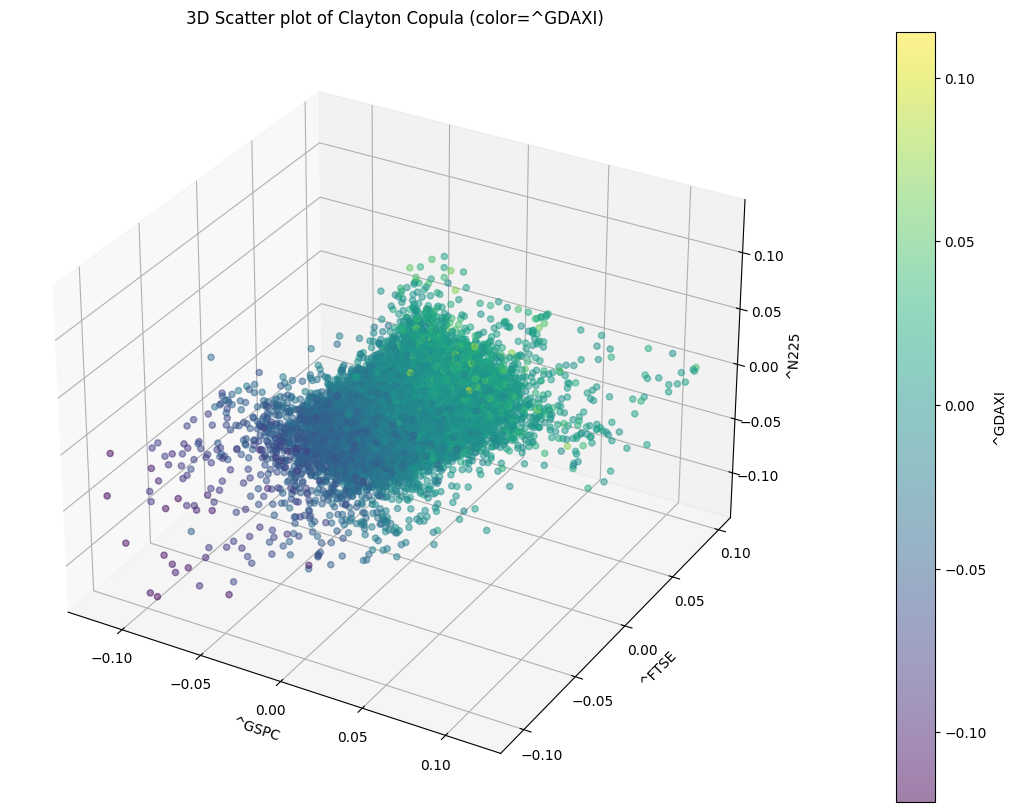

In [ ]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# Use U[:, 3] as the color
sc = ax.scatter(U_scaled[:, 0], U_scaled[:, 1], U_scaled[:, 2], c=U_scaled[:, 3], cmap='viridis', alpha=0.5)
ax.set_xlabel('^GSPC')
ax.set_ylabel('^FTSE')
ax.set_zlabel('^N225')
ax.set_title('3D Scatter plot of Clayton Copula (color=^GDAXI)')

# Add a colorbar
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('^GDAXI')

plt.show()


Portfolio Statistics:
95% VaR: -0.0160
95% Expected Shortfall: -0.0251


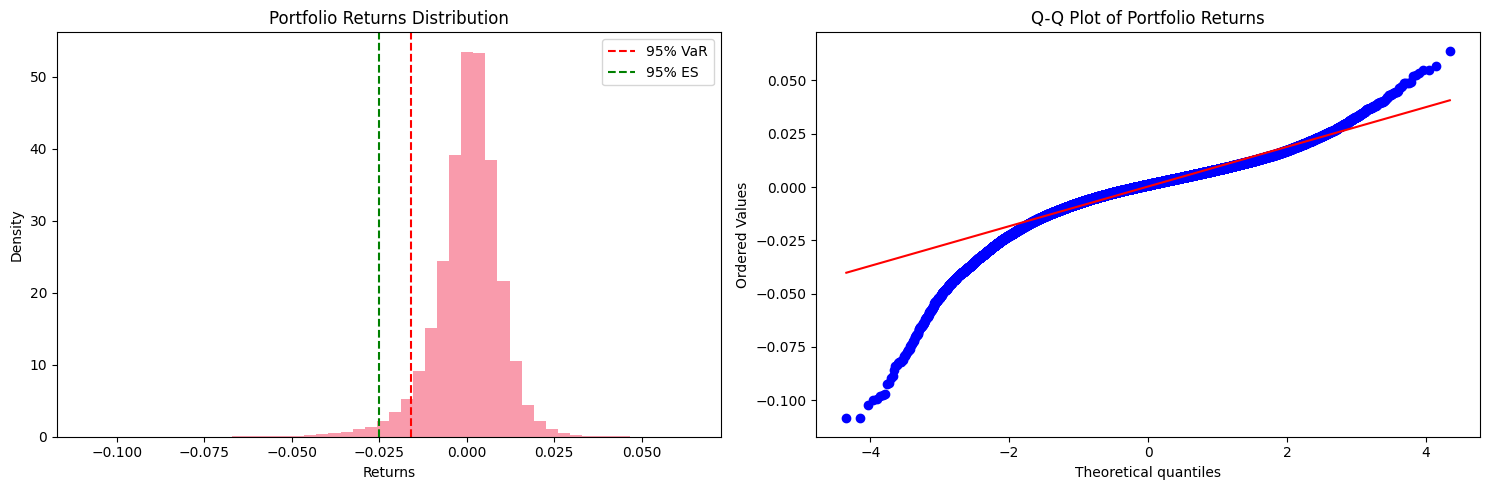


Additional Portfolio Metrics:
Mean Return: 0.0003
Standard Deviation: 0.0096
Skewness: -1.1242
Kurtosis: 6.0182


In [24]:
from scipy import stats


WEIGHTS = np.array([0.25, 0.25, 0.25, 0.25])
portfolio = np.dot(WEIGHTS, U_scaled.T)

# Calculate VaR and ES
VaR_95 = np.percentile(portfolio, 5)
ES_95 = np.mean(portfolio[portfolio <= VaR_95])

print(f"\nPortfolio Statistics:")
print(f"95% VaR: {VaR_95:.4f}")
print(f"95% Expected Shortfall: {ES_95:.4f}")

# Plot portfolio returns distribution
plt.figure(figsize=(15, 5))

# Histogram of portfolio returns
plt.subplot(121)
plt.hist(portfolio, bins=50, density=True, alpha=0.7)
plt.axvline(VaR_95, color='r', linestyle='dashed', label='95% VaR')
plt.axvline(ES_95, color='g', linestyle='dashed', label='95% ES')
plt.title('Portfolio Returns Distribution')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.legend()

# QQ plot of portfolio returns
plt.subplot(122)
stats.probplot(portfolio, dist="norm", plot=plt)
plt.title('Q-Q Plot of Portfolio Returns')

plt.tight_layout()
plt.show()

# Calculate some additional portfolio metrics
print(f"\nAdditional Portfolio Metrics:")
print(f"Mean Return: {np.mean(portfolio):.4f}")
print(f"Standard Deviation: {np.std(portfolio):.4f}")
print(f"Skewness: {stats.skew(portfolio):.4f}")
print(f"Kurtosis: {stats.kurtosis(portfolio):.4f}")